In [1]:
import os
import time
import copy
import itertools
import numpy as np
import pandas as pd
from scipy.stats import entropy as shannon_entropy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report)
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cpu")
print("Using device:", DEVICE)

Using device: cpu


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
BASE_DIR = r"C:\Users\parth\Downloads\UCDavis"

CLASS_DIRS = {
    "Google Doc": "Google Doc",
    "YouTube": "YouTube",
    "Google Search": "Google Search",
    "Google Music": "Google Music",
    "Google Drive": "Google Drive",
}

MAX_SEQ_LEN = 60
MIN_PACKETS = 5
LARGE_PKT_THRESHOLD = 1000
SMALL_PKT_THRESHOLD = 100

print("Configured classes:", list(CLASS_DIRS.keys()))

Configured classes: ['Google Doc', 'YouTube', 'Google Search', 'Google Music', 'Google Drive']


In [4]:
def parse_flow_file(filepath):
    try:
        df = pd.read_csv(
            filepath, sep="\t", header=None,
            names=["abs_time", "rel_time", "size", "direction"]
        )
        if df.empty or len(df) < MIN_PACKETS:
            return None
        return df
    except Exception as e:
        print(f"Failed to parse {filepath}: {e}")
        return None

In [5]:
def load_all_flows(base_dir, class_dirs):
    flows = []
    for label, folder in class_dirs.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            print(f"WARNING: folder not found -> {folder_path}")
            continue
        files = [f for f in os.listdir(folder_path) if f.endswith(".txt")]
        loaded = 0
        for fname in files:
            fpath = os.path.join(folder_path, fname)
            df = parse_flow_file(fpath)
            if df is not None:
                flows.append({"label": label, "df": df, "file": fname})
                loaded += 1
        print(f"{label}: loaded {loaded}/{len(files)} files")
    return flows

flows = load_all_flows(BASE_DIR, CLASS_DIRS)
print("\nTotal flows loaded:", len(flows))

Google Doc: loaded 1221/1221 files
YouTube: loaded 1077/1077 files
Google Search: loaded 1915/1915 files
Google Music: loaded 592/592 files
Google Drive: loaded 1634/1634 files

Total flows loaded: 6439


In [6]:
label_counts = pd.Series([f["label"] for f in flows]).value_counts()
print(label_counts)
flows[0]["df"].head(10)

Google Search    1915
Google Drive     1634
Google Doc       1221
YouTube          1077
Google Music      592
Name: count, dtype: int64


,abs_time,rel_time,size,direction
0,1.527993e+09,0.000000,354,1
1,1.527993e+09,0.032811,87,0
2,1.527993e+09,0.261392,323,0
3,1.527993e+09,0.262656,1412,0
4,1.527993e+09,0.263943,1412,0
5,1.527993e+09,0.264629,107,1
6,1.527993e+09,0.265175,1412,0
7,1.527993e+09,0.266366,180,0
8,1.527993e+09,0.267602,1412,0
9,1.527993e+09,0.267782,98,1


In [7]:
def extract_statistical_features(df):
    sizes = df["size"].values.astype(float)
    directions = df["direction"].values.astype(float)
    times = df["rel_time"].values.astype(float)
    iats = np.diff(times, prepend=times[0])

    total_pkts = len(df)
    total_bytes = sizes.sum()
    flow_duration = times.max() - times.min() if len(times) > 1 else 1e-6

    feats = {
        "total_pkts": total_pkts,
        "total_bytes": total_bytes,
        "flow_duration": flow_duration,
        "avg_pkt_size": sizes.mean(),
        "std_pkt_size": sizes.std(),
        "min_pkt_size": sizes.min(),
        "max_pkt_size": sizes.max(),
        "avg_iat": iats.mean(),
        "std_iat": iats.std(),
        "max_iat": iats.max(),
        "pkt_rate": total_pkts / flow_duration,
        "byte_rate": total_bytes / flow_duration,
        "dir_ratio": directions.mean(),
    }
    return feats

In [8]:
def _longest_run(mask):
    best = cur = 0
    for v in mask:
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return best

def _avg_run(mask):
    runs, cur = [], 0
    for v in mask:
        if v:
            cur += 1
        elif cur > 0:
            runs.append(cur)
            cur = 0
    if cur > 0:
        runs.append(cur)
    return np.mean(runs) if runs else 0.0

def extract_burst_features(df):
    directions = df["direction"].values
    sizes = df["size"].values.astype(float)
    times = df["rel_time"].values.astype(float)
    total_pkts = len(df)

    burst_ids = np.zeros(total_pkts, dtype=int)
    bid = 0
    for i in range(1, total_pkts):
        if directions[i] != directions[i - 1]:
            bid += 1
        burst_ids[i] = bid
    n_bursts = bid + 1

    burst_lengths, burst_durations, burst_avg_sizes = [], [], []
    for b in range(n_bursts):
        idx = np.where(burst_ids == b)[0]
        burst_lengths.append(len(idx))
        burst_durations.append(times[idx].max() - times[idx].min() if len(idx) > 1 else 0.0)
        burst_avg_sizes.append(sizes[idx].mean())

    burst_lengths = np.array(burst_lengths)
    burst_durations = np.array(burst_durations)
    burst_avg_sizes = np.array(burst_avg_sizes)

    payload_bursts = burst_avg_sizes > LARGE_PKT_THRESHOLD
    ack_bursts = burst_avg_sizes <= SMALL_PKT_THRESHOLD

    hist_sizes, _ = np.histogram(sizes, bins=10, range=(0, 1500))
    pkt_size_entropy = shannon_entropy(hist_sizes + 1e-9)

    hist_bursts, _ = np.histogram(burst_lengths, bins=10, range=(1, max(burst_lengths.max(), 2)))
    burst_len_entropy = shannon_entropy(hist_bursts + 1e-9)

    large_mask = sizes > LARGE_PKT_THRESHOLD
    small_mask = sizes <= SMALL_PKT_THRESHOLD

    feats = {
        "n_bursts": n_bursts,
        "avg_burst_length": burst_lengths.mean(),
        "std_burst_length": burst_lengths.std(),
        "max_burst_length": burst_lengths.max(),
        "avg_burst_duration": burst_durations.mean(),
        "std_burst_duration": burst_durations.std(),
        "payload_burst_ratio": payload_bursts.mean() if n_bursts > 0 else 0.0,
        "ack_burst_ratio": ack_bursts.mean() if n_bursts > 0 else 0.0,
        "avg_payload_burst_size": burst_avg_sizes[payload_bursts].mean() if payload_bursts.any() else 0.0,
        "avg_ack_burst_size": burst_avg_sizes[ack_bursts].mean() if ack_bursts.any() else 0.0,
        "direction_switch_rate": n_bursts / total_pkts,
        "packet_size_entropy": pkt_size_entropy,
        "burst_length_entropy": burst_len_entropy,
        "consecutive_large_pkt_max": _longest_run(large_mask),
        "consecutive_large_pkt_avg": _avg_run(large_mask),
        "consecutive_ack_max": _longest_run(small_mask),
        "consecutive_ack_avg": _avg_run(small_mask),
    }
    return feats

In [9]:
def flow_to_sequence(df, max_len=MAX_SEQ_LEN):
    d = df.copy()
    d["iat"] = d["rel_time"].diff().fillna(0.0)
    d["log_size"] = np.log1p(d["size"])
    d["log_iat"] = np.log1p(d["iat"].clip(lower=0))

    seq = d[["log_size", "direction", "log_iat", "rel_time"]].values.astype(np.float32)

    if len(seq) >= max_len:
        seq = seq[:max_len]
    else:
        pad = np.zeros((max_len - len(seq), 4), dtype=np.float32)
        seq = np.vstack([seq, pad])
    return seq

In [10]:
seq_list, stat_list, burst_list, labels = [], [], [], []

for f in flows:
    seq_list.append(flow_to_sequence(f["df"]))
    stat_list.append(extract_statistical_features(f["df"]))
    burst_list.append(extract_burst_features(f["df"]))
    labels.append(f["label"])

X_seq = np.stack(seq_list)
X_stat_df = pd.DataFrame(stat_list)
X_burst_df = pd.DataFrame(burst_list)
y_raw = np.array(labels)

print("X_seq:", X_seq.shape, "| X_stat:", X_stat_df.shape, "| X_burst:", X_burst_df.shape)

X_seq: (6439, 60, 4) | X_stat: (6439, 13) | X_burst: (6439, 17)


In [11]:
le = LabelEncoder()
y = le.fit_transform(y_raw)
n_classes = len(le.classes_)
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

n, t, c = X_seq.shape
seq_scaler = StandardScaler()
X_seq_scaled = seq_scaler.fit_transform(X_seq.reshape(-1, c)).reshape(n, t, c).astype(np.float32)

stat_scaler = StandardScaler()
X_stat_scaled = stat_scaler.fit_transform(X_stat_df.values).astype(np.float32)

burst_scaler = StandardScaler()
X_burst_scaled = burst_scaler.fit_transform(X_burst_df.values).astype(np.float32)

indices = np.arange(n)
idx_train, idx_temp = train_test_split(indices, test_size=0.3, stratify=y, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, stratify=y[idx_temp], random_state=42)

def subset(idx):
    return X_seq_scaled[idx], X_stat_scaled[idx], X_burst_scaled[idx], y[idx]

X_seq_train, X_stat_train, X_burst_train, y_train = subset(idx_train)
X_seq_val,   X_stat_val,   X_burst_val,   y_val   = subset(idx_val)
X_seq_test,  X_stat_test,  X_burst_test,  y_test  = subset(idx_test)

print("Train:", len(idx_train), "Val:", len(idx_val), "Test:", len(idx_test))

Class mapping: {np.str_('Google Doc'): np.int64(0), np.str_('Google Drive'): np.int64(1), np.str_('Google Music'): np.int64(2), np.str_('Google Search'): np.int64(3), np.str_('YouTube'): np.int64(4)}
Train: 4507 Val: 966 Test: 966


In [12]:
class QUICMultiDataset(Dataset):
    def __init__(self, X_seq, X_stat, X_burst, y):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_stat = torch.tensor(X_stat, dtype=torch.float32)
        self.X_burst = torch.tensor(X_burst, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_stat[idx], self.X_burst[idx], self.y[idx]

def make_loaders(batch_size):
    train_ds = QUICMultiDataset(X_seq_train, X_stat_train, X_burst_train, y_train)
    val_ds   = QUICMultiDataset(X_seq_val,   X_stat_val,   X_burst_val,   y_val)
    test_ds  = QUICMultiDataset(X_seq_test,  X_stat_test,  X_burst_test,  y_test)
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True),
            DataLoader(val_ds, batch_size=batch_size, shuffle=False),
            DataLoader(test_ds, batch_size=batch_size, shuffle=False))

train_loader, val_loader, test_loader = make_loaders(batch_size=64)

## Encoders

In [13]:
SEQ_INPUT_DIM = 4

In [14]:
class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.chomp = pad
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def _chomp(self, x):
        return x[:, :, :-self.chomp] if self.chomp > 0 else x

    def forward(self, x):
        out = self.relu(self._chomp(self.conv1(x)))
        out = self.dropout(out)
        out = self.relu(self._chomp(self.conv2(out)))
        out = self.dropout(out)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TCNEncoder(nn.Module):
    def __init__(self, input_dim=SEQ_INPUT_DIM, channels=(16, 16, 32), kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        in_ch = input_dim
        for i, out_ch in enumerate(channels):
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation=2 ** i, dropout=dropout))
            in_ch = out_ch
        self.net = nn.Sequential(*layers)
        self.out_dim = channels[-1]
        self.last_activation = None

    def forward(self, x):
        h = self.net(x.permute(0, 2, 1))
        self.last_activation = h
        if h.requires_grad:
            h.retain_grad()
        pooled = h.mean(dim=2)
        return pooled

In [15]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        res = x if self.downsample is None else self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        return self.relu(out + res)

class ResNet1DEncoder(nn.Module):
    def __init__(self, input_dim=SEQ_INPUT_DIM, channels=(16, 32), dropout=0.2):
        super().__init__()
        blocks = []
        in_ch = input_dim
        for out_ch in channels:
            blocks.append(ResBlock1D(in_ch, out_ch, dropout=dropout))
            in_ch = out_ch
        self.net = nn.Sequential(*blocks)
        self.out_dim = channels[-1]
        self.last_activation = None

    def forward(self, x):
        h = self.net(x.permute(0, 2, 1))
        self.last_activation = h
        if h.requires_grad:
            h.retain_grad()
        pooled = h.mean(dim=2)
        return pooled

In [16]:
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        scores = self.attn(x).squeeze(-1)
        weights = F.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), x).squeeze(1)
        return context, weights

class CNNBiGRUAttnEncoder(nn.Module):
    def __init__(self, input_dim=SEQ_INPUT_DIM, cnn_channels=16, gru_hidden=32, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, cnn_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.bigru = nn.GRU(cnn_channels, gru_hidden, batch_first=True, bidirectional=True)
        self.attention = AdditiveAttention(gru_hidden * 2)
        self.out_dim = gru_hidden * 2
        self.last_attn_weights = None

    def forward(self, x):
        h = self.conv(x.permute(0, 2, 1)).permute(0, 2, 1)
        h, _ = self.bigru(h)
        context, weights = self.attention(h)
        self.last_attn_weights = weights.detach()
        return context

In [17]:
SEQ_ENCODERS = {
    "TCN": TCNEncoder,
    "ResNet1D": ResNet1DEncoder,
    "CNN_BiGRU_Attn": CNNBiGRUAttnEncoder,
}

## Fusion

In [18]:
class MultiBranchNet(nn.Module):
    def __init__(self, seq_encoder_name, stat_dim, burst_dim, n_classes,
                 use_seq=True, use_stat=True, use_burst=True,
                 branch_hidden=32, dropout=0.3):
        super().__init__()
        self.use_seq, self.use_stat, self.use_burst = use_seq, use_stat, use_burst

        fusion_dim = 0
        if use_seq:
            self.seq_encoder = SEQ_ENCODERS[seq_encoder_name](dropout=dropout)
            fusion_dim += self.seq_encoder.out_dim
        if use_stat:
            self.stat_mlp = nn.Sequential(
                nn.Linear(stat_dim, branch_hidden), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(branch_hidden, branch_hidden), nn.ReLU(),
            )
            fusion_dim += branch_hidden
        if use_burst:
            self.burst_mlp = nn.Sequential(
                nn.Linear(burst_dim, branch_hidden), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(branch_hidden, branch_hidden), nn.ReLU(),
            )
            fusion_dim += branch_hidden

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x_seq, x_stat, x_burst):
        parts = []
        if self.use_seq:
            parts.append(self.seq_encoder(x_seq))
        if self.use_stat:
            parts.append(self.stat_mlp(x_stat))
        if self.use_burst:
            parts.append(self.burst_mlp(x_burst))
        fused = torch.cat(parts, dim=1)
        return self.classifier(fused)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_mb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)

In [19]:
def train_with_early_stopping(model, train_loader, val_loader, max_epochs=40,
                                lr=1e-3, patience=6, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(max_epochs):
        model.train()
        total_loss = 0.0
        for x_seq, x_stat, x_burst, y_batch in train_loader:
            optimizer.zero_grad()
            out = model(x_seq, x_stat, x_burst)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x_seq.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for x_seq, x_stat, x_burst, y_batch in val_loader:
                out = model(x_seq, x_stat, x_burst)
                loss = criterion(out, y_batch)
                val_loss += loss.item() * x_seq.size(0)
                correct += (out.argmax(1) == y_batch).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch+1}/{max_epochs} | train_loss={train_loss:.4f} "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} lr={lr_now:.2e}")

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history

In [20]:
def evaluate_model(model, loader, class_names, label="Model", plot=True):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_stat, x_burst, y_batch in loader:
            out = model(x_seq, x_stat, x_burst)
            all_preds.extend(out.argmax(1).numpy())
            all_labels.extend(y_batch.numpy())

    single_loader = DataLoader(loader.dataset, batch_size=1, shuffle=False)
    start = time.time()
    with torch.no_grad():
        for x_seq, x_stat, x_burst, y_batch in single_loader:
            _ = model(x_seq, x_stat, x_burst)
    elapsed = time.time() - start
    n_samples = len(loader.dataset)
    per_sample_ms = elapsed / n_samples * 1000

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)

    print(f"--- {label} ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"Inference: {per_sample_ms:.4f} ms/sample (batch=1) | Params: {count_params(model):,} "
          f"| Size: {model_size_mb(model):.3f} MB")

    if plot:
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {label}")
        plt.xlabel("Predicted"); plt.ylabel("True")
        plt.tight_layout(); plt.show()

    return {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "inference_ms_per_sample": per_sample_ms,
        "n_params": count_params(model), "size_mb": model_size_mb(model),
    }

In [21]:
arch_results = {}
arch_models = {}

for arch_name in SEQ_ENCODERS.keys():
    print(f"\nTraining {arch_name}")
    m = MultiBranchNet(arch_name, X_stat_scaled.shape[1], X_burst_scaled.shape[1], n_classes,
                        use_seq=True, use_stat=True, use_burst=True, dropout=0.3)
    m, hist = train_with_early_stopping(m, train_loader, val_loader, max_epochs=40, patience=6, verbose=False)
    res = evaluate_model(m, test_loader, le.classes_, label=arch_name, plot=False)
    arch_results[arch_name] = res
    arch_models[arch_name] = m

arch_comparison = pd.DataFrame(arch_results).T
arch_comparison.sort_values("f1", ascending=False)


Training TCN
--- TCN ---
Accuracy: 0.9959 | Precision: 0.9932 | Recall: 0.9954 | F1: 0.9943
Inference: 2.1019 ms/sample (batch=1) | Params: 17,525 | Size: 0.067 MB

Training ResNet1D
--- ResNet1D ---
Accuracy: 0.9979 | Precision: 0.9971 | Recall: 0.9969 | F1: 0.9970
Inference: 1.5597 ms/sample (batch=1) | Params: 16,149 | Size: 0.062 MB

Training CNN_BiGRU_Attn
--- CNN_BiGRU_Attn ---
Accuracy: 0.9990 | Precision: 0.9988 | Recall: 0.9978 | F1: 0.9983
Inference: 10.0965 ms/sample (batch=1) | Params: 21,590 | Size: 0.082 MB


,accuracy,precision,recall,f1,inference_ms_per_sample,n_params,size_mb
CNN_BiGRU_Attn,0.998965,0.998765,0.997753,0.998251,10.096541,21590.0,0.082359
ResNet1D,0.997930,0.997061,0.996936,0.996997,1.559738,16149.0,0.061604
TCN,0.995859,0.993234,0.995426,0.994316,2.101874,17525.0,0.066853


In [22]:
BEST_ARCH = arch_comparison["f1"].idxmax()
print("Best sequence architecture:", BEST_ARCH)

Best sequence architecture: CNN_BiGRU_Attn


In [23]:
BEST_DROPOUT = 0.2
BEST_HIDDEN = 64
BEST_BATCH = 32
BEST_LR = 0.001
train_loader, val_loader, test_loader = make_loaders(batch_size=BEST_BATCH)
print(
    f"Final config -> arch={BEST_ARCH}, "
    f"dropout={BEST_DROPOUT}, "
    f"hidden={BEST_HIDDEN}, "
    f"batch={BEST_BATCH}, "
    f"lr={BEST_LR}"
)

Final config -> arch=CNN_BiGRU_Attn, dropout=0.2, hidden=64, batch=32, lr=0.001


## Ablation

In [24]:
ablation_configs = {
    "Statistical only":          dict(use_seq=False, use_stat=True,  use_burst=False),
    "Sequence only":             dict(use_seq=True,  use_stat=False, use_burst=False),
    "Burst only":                dict(use_seq=False, use_stat=False, use_burst=True),
    "Statistical + Seq + Burst": dict(use_seq=True,  use_stat=True,  use_burst=True),
}

ablation_results = {}
ablation_models = {}

for name, flags in ablation_configs.items():
    print(f"\n Ablation: {name}")
    m = MultiBranchNet(BEST_ARCH, X_stat_scaled.shape[1], X_burst_scaled.shape[1], n_classes,
                        branch_hidden=BEST_HIDDEN, dropout=BEST_DROPOUT, **flags)
    m, hist = train_with_early_stopping(m, train_loader, val_loader, max_epochs=40, lr=BEST_LR, patience=6, verbose=False)
    res = evaluate_model(m, test_loader, le.classes_, label=name, plot=False)
    ablation_results[name] = res
    ablation_models[name] = m

ablation_df = pd.DataFrame(ablation_results).T
ablation_df.sort_values("f1", ascending=False)


 Ablation: Statistical only
--- Statistical only ---
Accuracy: 0.9896 | Precision: 0.9862 | Recall: 0.9853 | F1: 0.9857
Inference: 0.3853 ms/sample (batch=1) | Params: 9,541 | Size: 0.036 MB

 Ablation: Sequence only
--- Sequence only ---
Accuracy: 0.9814 | Precision: 0.9808 | Recall: 0.9778 | F1: 0.9791
Inference: 6.6362 ms/sample (batch=1) | Params: 14,358 | Size: 0.055 MB

 Ablation: Burst only
--- Burst only ---
Accuracy: 0.9814 | Precision: 0.9784 | Recall: 0.9734 | F1: 0.9758
Inference: 0.2376 ms/sample (batch=1) | Params: 9,797 | Size: 0.037 MB

 Ablation: Statistical + Seq + Burst
--- Statistical + Seq + Burst ---
Accuracy: 0.9979 | Precision: 0.9985 | Recall: 0.9965 | F1: 0.9975
Inference: 7.1480 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB


,accuracy,precision,recall,f1,inference_ms_per_sample,n_params,size_mb
Statistical + Seq + Burst,0.997930,0.998495,0.996511,0.997493,7.147983,32918.0,0.125572
Statistical only,0.989648,0.986153,0.985261,0.985696,0.385326,9541.0,0.036396
Sequence only,0.981366,0.980842,0.977774,0.979104,6.636244,14358.0,0.054771
Burst only,0.981366,0.978436,0.973436,0.975832,0.237645,9797.0,0.037373


                           accuracy  precision    recall        f1  \
Statistical + Seq + Burst  0.997930   0.998495  0.996511  0.997493   
Statistical only           0.989648   0.986153  0.985261  0.985696   
Sequence only              0.981366   0.980842  0.977774  0.979104   
Burst only                 0.981366   0.978436  0.973436  0.975832   

                           inference_ms_per_sample  n_params   size_mb  
Statistical + Seq + Burst                 7.147983   32918.0  0.125572  
Statistical only                          0.385326    9541.0  0.036396  
Sequence only                             6.636244   14358.0  0.054771  
Burst only                                0.237645    9797.0  0.037373  


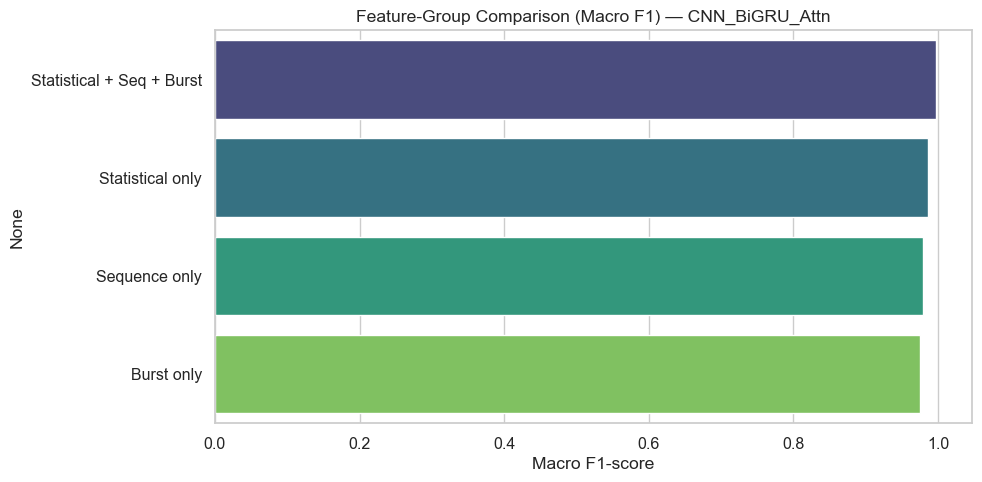

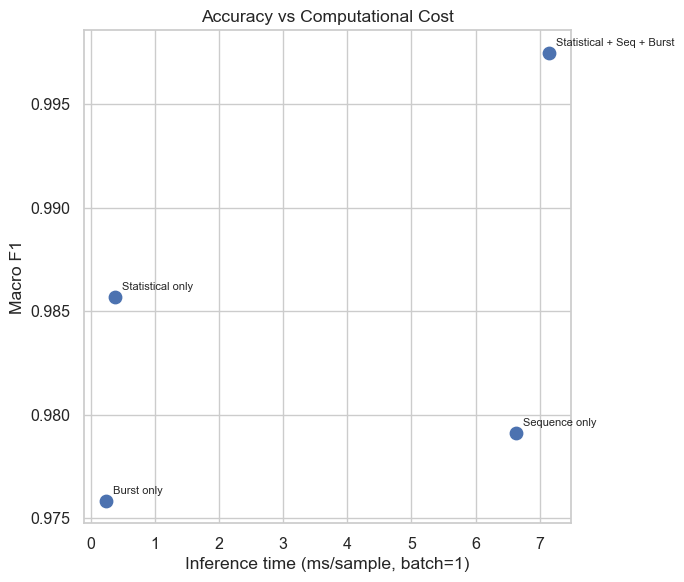

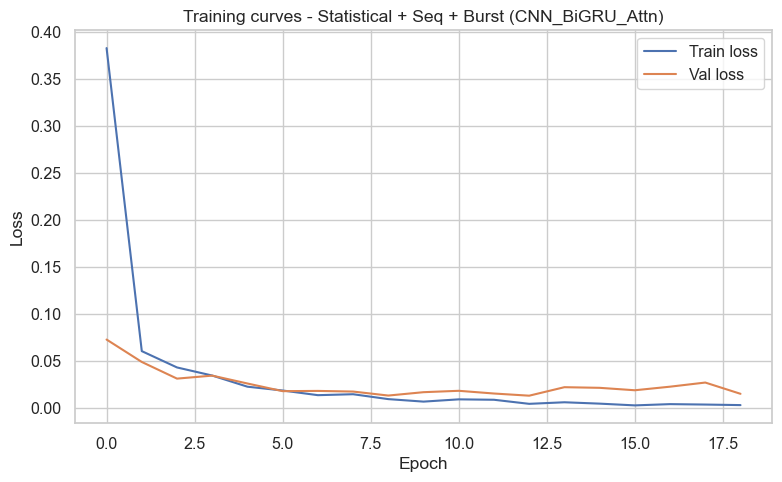

In [31]:
final_table = ablation_df.copy()
final_table = final_table.sort_values("f1", ascending=False)
print(final_table)

plt.figure(figsize=(10, 5))
order = final_table.index
sns.barplot(x=final_table["f1"].values, y=order, hue=order, palette="viridis", legend=False)
plt.xlabel("Macro F1-score")
plt.title(f"Feature-Group Comparison (Macro F1) — {BEST_ARCH}")
plt.tight_layout()
plt.savefig("f1_comparison.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(final_table["inference_ms_per_sample"], final_table["f1"], s=80)
for name, row in final_table.iterrows():
    plt.annotate(name, (row["inference_ms_per_sample"], row["f1"]), fontsize=8, xytext=(5, 5), textcoords="offset points")
plt.xlabel("Inference time (ms/sample, batch=1)")
plt.ylabel("Macro F1")
plt.title("Accuracy vs Computational Cost")
plt.tight_layout()
plt.savefig("efficiency_tradeoff.png", dpi=300)
plt.show()

best_model_name = ablation_df["f1"].idxmax()
_, best_hist = train_with_early_stopping(
    MultiBranchNet(BEST_ARCH, X_stat_scaled.shape[1], X_burst_scaled.shape[1], n_classes,
                   branch_hidden=BEST_HIDDEN, dropout=BEST_DROPOUT,
                   **ablation_configs[best_model_name]),
    train_loader, val_loader, max_epochs=40, lr=BEST_LR, patience=6, verbose=False)

plt.figure(figsize=(8, 5))
plt.plot(best_hist["train_loss"], label="Train loss")
plt.plot(best_hist["val_loss"], label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title(f"Training curves - {best_model_name} ({BEST_ARCH})")
plt.legend(); plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()

In [26]:
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

cv_results = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_seq_scaled, y), start=1):
    print(f"\n===== Fold {fold}/{N_FOLDS} =====")

    # carve a small validation slice out of this fold's training portion for early stopping
    tr_idx, va_idx = train_test_split(train_idx, test_size=0.15, stratify=y[train_idx], random_state=42)

    def subset_cv(idx):
        return X_seq_scaled[idx], X_stat_scaled[idx], X_burst_scaled[idx], y[idx]

    Xs_tr, Xt_tr, Xb_tr, y_tr = subset_cv(tr_idx)
    Xs_va, Xt_va, Xb_va, y_va = subset_cv(va_idx)
    Xs_te, Xt_te, Xb_te, y_te = subset_cv(test_idx)

    tr_ds = QUICMultiDataset(Xs_tr, Xt_tr, Xb_tr, y_tr)
    va_ds = QUICMultiDataset(Xs_va, Xt_va, Xb_va, y_va)
    te_ds = QUICMultiDataset(Xs_te, Xt_te, Xb_te, y_te)

    g = torch.Generator(); g.manual_seed(42)
    tr_loader = DataLoader(tr_ds, batch_size=BEST_BATCH, shuffle=True, generator=g)
    va_loader = DataLoader(va_ds, batch_size=BEST_BATCH, shuffle=False)
    te_loader = DataLoader(te_ds, batch_size=BEST_BATCH, shuffle=False)

    torch.manual_seed(42)  # reset before each fold's model init
    m = MultiBranchNet(BEST_ARCH, X_stat_scaled.shape[1], X_burst_scaled.shape[1], n_classes,
                        use_seq=True, use_stat=True, use_burst=True,
                        branch_hidden=BEST_HIDDEN, dropout=BEST_DROPOUT)
    m, _ = train_with_early_stopping(m, tr_loader, va_loader, max_epochs=40, lr=BEST_LR, patience=6, verbose=False)
    res = evaluate_model(m, te_loader, le.classes_, label=f"Fold {fold}", plot=False)
    cv_results.append(res)

cv_df = pd.DataFrame(cv_results)
print("\n===== Cross-Validation Summary (Statistical + Seq + Burst, {} folds) =====".format(N_FOLDS))
print(cv_df[["accuracy", "precision", "recall", "f1"]])
print("\nMean ± Std:")
for col in ["accuracy", "precision", "recall", "f1"]:
    print(f"  {col}: {cv_df[col].mean():.4f} ± {cv_df[col].std():.4f}")


===== Fold 1/5 =====
--- Fold 1 ---
Accuracy: 0.9984 | Precision: 0.9967 | Recall: 0.9985 | F1: 0.9975
Inference: 6.7881 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

===== Fold 2/5 =====
--- Fold 2 ---
Accuracy: 0.9992 | Precision: 0.9994 | Recall: 0.9983 | F1: 0.9988
Inference: 6.3896 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

===== Fold 3/5 =====
--- Fold 3 ---
Accuracy: 0.9969 | Precision: 0.9959 | Recall: 0.9941 | F1: 0.9950
Inference: 6.7387 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

===== Fold 4/5 =====
--- Fold 4 ---
Accuracy: 0.9953 | Precision: 0.9946 | Recall: 0.9950 | F1: 0.9948
Inference: 7.6560 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

===== Fold 5/5 =====
--- Fold 5 ---
Accuracy: 0.9938 | Precision: 0.9926 | Recall: 0.9895 | F1: 0.9910
Inference: 7.4041 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

===== Cross-Validation Summary (Statistical + Seq + Burst, 5 folds) =====
   accuracy  precision    recall        f1
0 

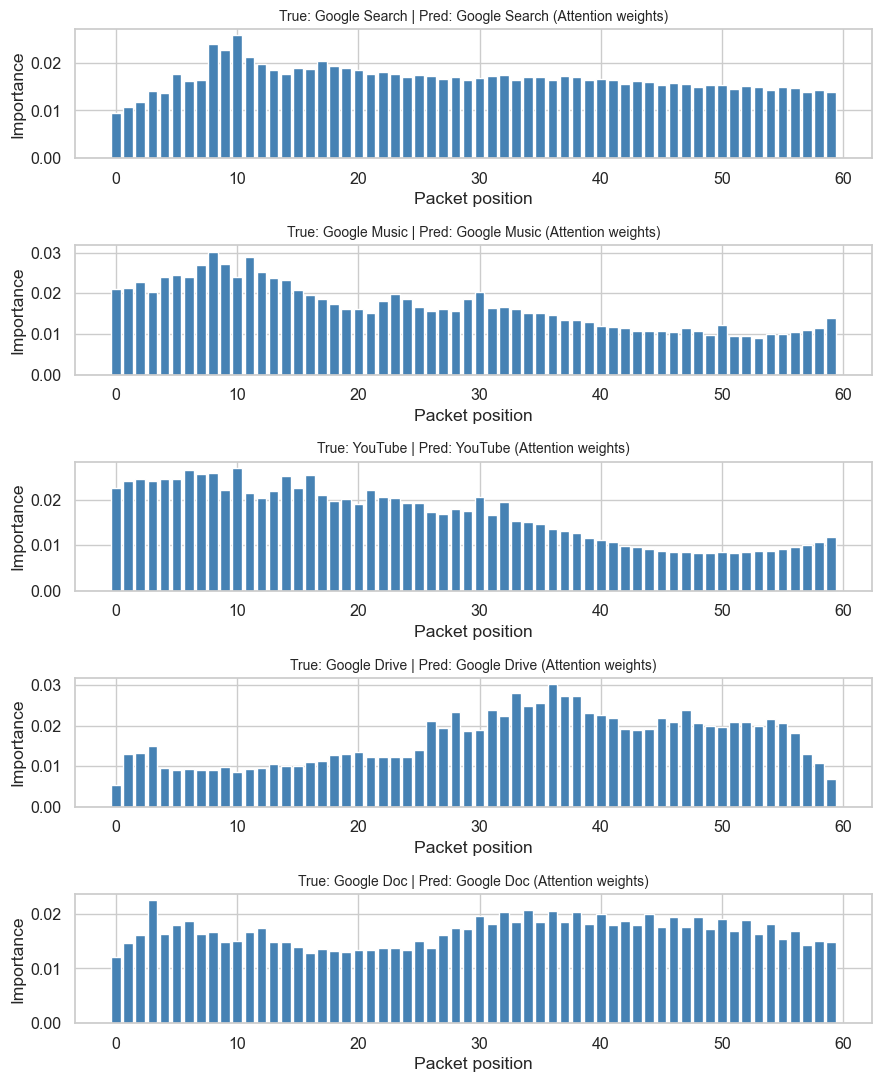

In [27]:
best_full_model = ablation_models["Statistical + Seq + Burst"]  # your best fused model, already trained
best_full_model.eval()

def compute_gradcam(model, x_seq, x_stat, x_burst, target_class):
    "Grad-CAM for TCN/ResNet1D encoders using last_activation + its gradient"
    model.zero_grad()
    x_seq = x_seq.clone().requires_grad_(True)
    out = model(x_seq, x_stat, x_burst)
    score = out[0, target_class]
    score.backward()

    activ = model.seq_encoder.last_activation        # shape: (1, channels, time)
    grad = activ.grad                                  # same shape, populated via retain_grad()
    weights = grad.mean(dim=2, keepdim=True)            # global-avg-pool the gradient :  channel weights
    cam = F.relu((weights * activ).sum(dim=1)).squeeze(0)  # (time,)
    cam = cam.detach().numpy()
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam

def get_attention_weights(model, x_seq, x_stat, x_burst):
    "For CNN_BiGRU_Attn: just run forward and read stored attention weights."
    with torch.no_grad():
        _ = model(x_seq, x_stat, x_burst)
    return model.seq_encoder.last_attn_weights.squeeze(0).numpy()

# pick a handful of test-set examples, one per class if possible
sample_idx = []
seen_classes = set()
for i in idx_test:
    lbl = y[i]
    if lbl not in seen_classes:
        sample_idx.append(i)
        seen_classes.add(lbl)
    if len(seen_classes) == n_classes:
        break

fig, axes = plt.subplots(len(sample_idx), 1, figsize=(9, 2.2 * len(sample_idx)))
if len(sample_idx) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_idx):
    x_seq_i = torch.tensor(X_seq_scaled[idx:idx+1], dtype=torch.float32)
    x_stat_i = torch.tensor(X_stat_scaled[idx:idx+1], dtype=torch.float32)
    x_burst_i = torch.tensor(X_burst_scaled[idx:idx+1], dtype=torch.float32)
    true_label = le.classes_[y[idx]]

    with torch.no_grad():
        pred_logits = best_full_model(x_seq_i, x_stat_i, x_burst_i)
        pred_class = pred_logits.argmax(1).item()

    if BEST_ARCH in ("TCN", "ResNet1D"):
        importance = compute_gradcam(best_full_model, x_seq_i, x_stat_i, x_burst_i, pred_class)
        xlabel = "Packet position"
        title_suffix = "Grad-CAM"
    else:  # CNN_BiGRU_Attn
        importance = get_attention_weights(best_full_model, x_seq_i, x_stat_i, x_burst_i)
        xlabel = "Packet position"
        title_suffix = "Attention weights"

    ax.bar(range(len(importance)), importance, color="steelblue")
    ax.set_title(f"True: {true_label} | Pred: {le.classes_[pred_class]} ({title_suffix})", fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Importance")

plt.tight_layout()
plt.savefig("interpretability_per_class.png", dpi=300)
plt.show()

Flows used per class: {np.str_('Google Doc'): 183, np.str_('Google Drive'): 245, np.str_('Google Music'): 88, np.str_('Google Search'): 288, np.str_('YouTube'): 160}


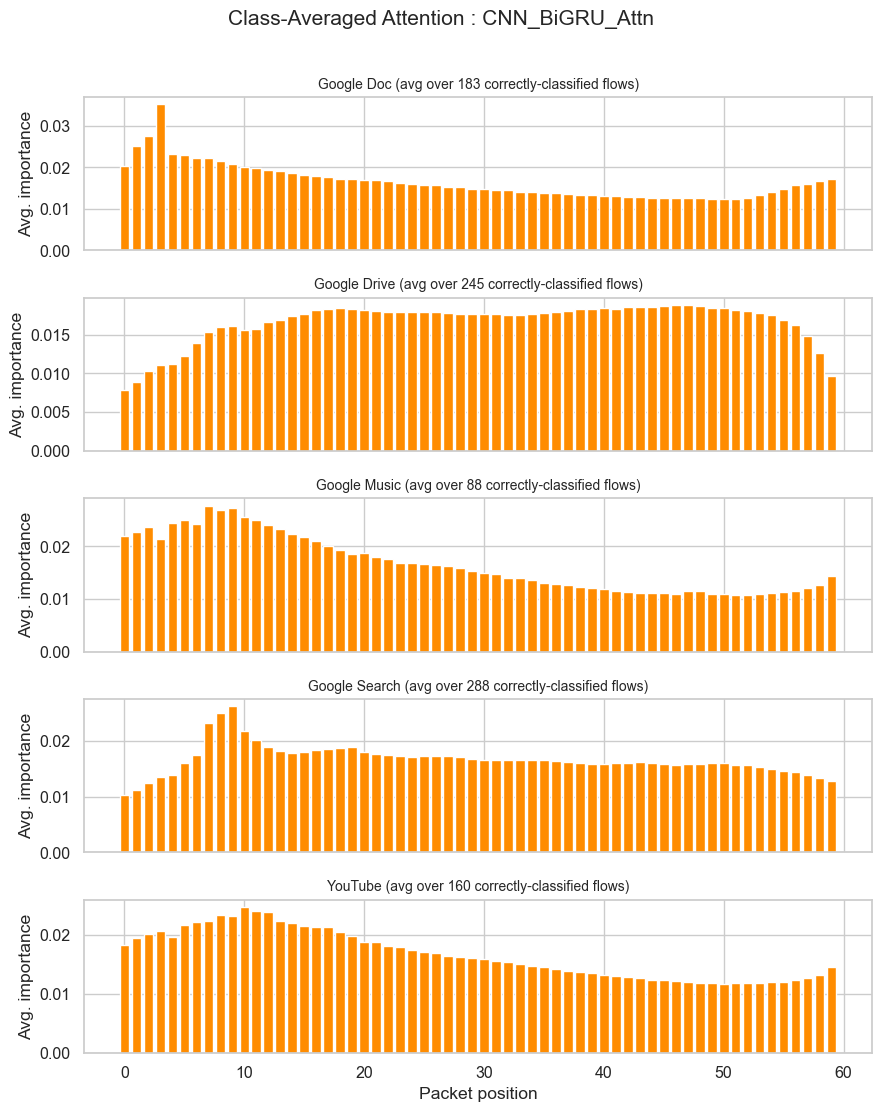


Most influential packet position per class:
  Google Doc: position 3 (importance=0.035)
  Google Drive: position 47 (importance=0.019)
  Google Music: position 7 (importance=0.028)
  Google Search: position 9 (importance=0.026)
  YouTube: position 10 (importance=0.025)


In [32]:
class_importance = {cls: [] for cls in le.classes_}

for idx in idx_test:
    x_seq_i = torch.tensor(X_seq_scaled[idx:idx+1], dtype=torch.float32)
    x_stat_i = torch.tensor(X_stat_scaled[idx:idx+1], dtype=torch.float32)
    x_burst_i = torch.tensor(X_burst_scaled[idx:idx+1], dtype=torch.float32)
    true_label = le.classes_[y[idx]]

    with torch.no_grad():
        pred_logits = best_full_model(x_seq_i, x_stat_i, x_burst_i)
        pred_class = pred_logits.argmax(1).item()

    if pred_class != y[idx]:
        continue  # only aggregate correctly-classified flows

    if BEST_ARCH in ("TCN", "ResNet1D"):
        importance = compute_gradcam(best_full_model, x_seq_i, x_stat_i, x_burst_i, pred_class)
    else:
        importance = get_attention_weights(best_full_model, x_seq_i, x_stat_i, x_burst_i)

    class_importance[true_label].append(importance)

avg_importance, n_used = {}, {}
for cls, arrs in class_importance.items():
    if len(arrs) == 0:
        print(f"WARNING: no correctly-classified test flows for class '{cls}'")
        continue
    stacked = np.stack(arrs)
    avg_importance[cls] = stacked.mean(axis=0)
    n_used[cls] = stacked.shape[0]

print("Flows used per class:", n_used)

fig, axes = plt.subplots(len(avg_importance), 1, figsize=(9, 2.2 * len(avg_importance)), sharex=True)
if len(avg_importance) == 1:
    axes = [axes]
for ax, (cls, imp) in zip(axes, avg_importance.items()):
    ax.bar(range(len(imp)), imp, color="darkorange")
    ax.set_title(f"{cls} (avg over {n_used[cls]} correctly-classified flows)", fontsize=10)
    ax.set_ylabel("Avg. importance")
axes[-1].set_xlabel("Packet position")
plt.suptitle(f"Class-Averaged {'Grad-CAM' if BEST_ARCH != 'CNN_BiGRU_Attn' else 'Attention'} : {BEST_ARCH}", y=1.01)
plt.tight_layout()
plt.savefig("interpretability_class_averaged.png", dpi=300)
plt.show()

print("\nMost influential packet position per class:")
for cls, imp in avg_importance.items():
    peak_pos = int(np.argmax(imp))
    print(f"  {cls}: position {peak_pos} (importance={imp[peak_pos]:.3f})")

## Early Packet Classification

In [29]:
def build_early_features(k):
    seq_list, stat_list, burst_list = [], [], []
    for f in flows:
        df_k = f["df"].iloc[:k].reset_index(drop=True)
        if len(df_k) < 2:
            df_k = f["df"].iloc[:2].reset_index(drop=True)
        seq_list.append(flow_to_sequence(df_k, max_len=k))
        stat_list.append(extract_statistical_features(df_k))
        burst_list.append(extract_burst_features(df_k))

    X_seq_k = np.stack(seq_list).astype(np.float32)
    X_stat_k = pd.DataFrame(stat_list).values.astype(np.float32)
    X_burst_k = pd.DataFrame(burst_list).values.astype(np.float32)
    return X_seq_k, X_stat_k, X_burst_k

print("Early-feature builder ready. Example shapes at K=10:")
xs, xt, xb = build_early_features(10)
print(xs.shape, xt.shape, xb.shape)

Early-feature builder ready. Example shapes at K=10:
(6439, 10, 4) (6439, 13) (6439, 17)



Early classification at K=5 packets
--- Fusion K=5 ---
Accuracy: 0.9679 | Precision: 0.9715 | Recall: 0.9566 | F1: 0.9630
Inference: 1.5235 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Early classification at K=10 packets
--- Fusion K=10 ---
Accuracy: 0.9772 | Precision: 0.9794 | Recall: 0.9735 | F1: 0.9762
Inference: 2.1260 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Early classification at K=15 packets
--- Fusion K=15 ---
Accuracy: 0.9834 | Precision: 0.9830 | Recall: 0.9759 | F1: 0.9790
Inference: 2.7445 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Early classification at K=20 packets
--- Fusion K=20 ---
Accuracy: 0.9834 | Precision: 0.9837 | Recall: 0.9785 | F1: 0.9809
Inference: 2.9240 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Early classification at K=30 packets
--- Fusion K=30 ---
Accuracy: 0.9834 | Precision: 0.9819 | Recall: 0.9752 | F1: 0.9780
Inference: 3.6420 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Early classifica

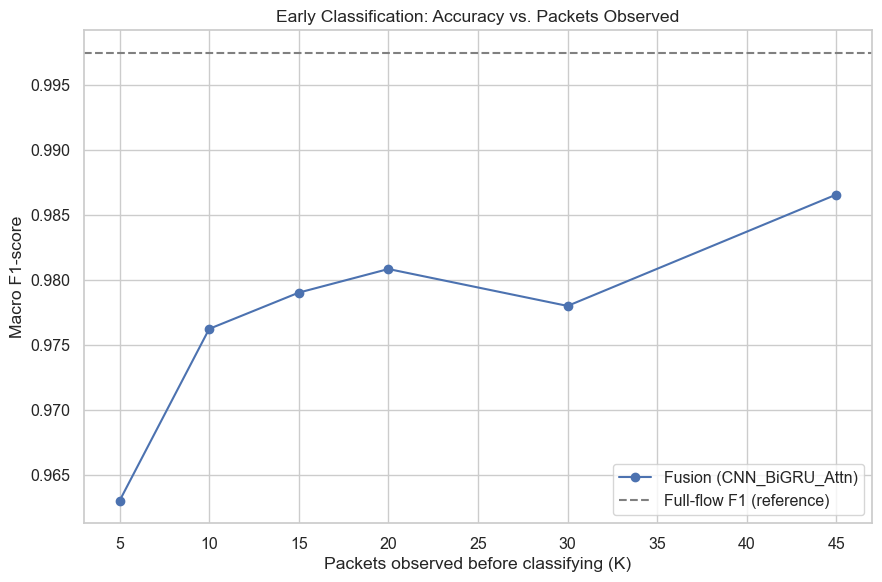

Reaches 95% of full-flow F1 (0.9476) at K = 5.0 packets


In [30]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

import random  # add if not already imported at the top

K_VALUES = [5, 10, 15, 20, 30, 45]
early_results = []

for K in K_VALUES:
    set_seed(42)   # reset before every K so results are comparable, not RNG-position-dependent
    print(f"\nEarly classification at K={K} packets")

    X_seq_k, X_stat_k, X_burst_k = build_early_features(K)
    n, t, c = X_seq_k.shape

    seq_sc_k = StandardScaler().fit(X_seq_k[idx_train].reshape(-1, c))
    X_seq_k_s = seq_sc_k.transform(X_seq_k.reshape(-1, c)).reshape(n, t, c).astype(np.float32)

    stat_sc_k = StandardScaler().fit(X_stat_k[idx_train])
    X_stat_k_s = stat_sc_k.transform(X_stat_k).astype(np.float32)

    burst_sc_k = StandardScaler().fit(X_burst_k[idx_train])
    X_burst_k_s = burst_sc_k.transform(X_burst_k).astype(np.float32)

    def subset_k(idx):
        return X_seq_k_s[idx], X_stat_k_s[idx], X_burst_k_s[idx], y[idx]

    Xs_tr, Xt_tr, Xb_tr, y_tr = subset_k(idx_train)
    Xs_va, Xt_va, Xb_va, y_va = subset_k(idx_val)
    Xs_te, Xt_te, Xb_te, y_te = subset_k(idx_test)

    tr_ds = QUICMultiDataset(Xs_tr, Xt_tr, Xb_tr, y_tr)
    va_ds = QUICMultiDataset(Xs_va, Xt_va, Xb_va, y_va)
    te_ds = QUICMultiDataset(Xs_te, Xt_te, Xb_te, y_te)

    g = torch.Generator(); g.manual_seed(42)
    tr_loader = DataLoader(tr_ds, batch_size=BEST_BATCH, shuffle=True, generator=g)
    va_loader = DataLoader(va_ds, batch_size=BEST_BATCH, shuffle=False)
    te_loader = DataLoader(te_ds, batch_size=BEST_BATCH, shuffle=False)

    m = MultiBranchNet(BEST_ARCH, X_stat_k_s.shape[1], X_burst_k_s.shape[1], n_classes,
                        use_seq=True, use_stat=True, use_burst=True,
                        branch_hidden=BEST_HIDDEN, dropout=BEST_DROPOUT)
    m, _ = train_with_early_stopping(m, tr_loader, va_loader, max_epochs=30, lr=BEST_LR, patience=5, verbose=False)
    res_nn = evaluate_model(m, te_loader, le.classes_, label=f"Fusion K={K}", plot=False)

    early_results.append({
        "K": K,
        "fusion_acc": res_nn["accuracy"],
        "fusion_precision": res_nn["precision"],
        "fusion_recall": res_nn["recall"],
        "fusion_f1": res_nn["f1"],
    })

early_df = pd.DataFrame(early_results)
print("\nEarly Classification Results")
print(early_df)

# ---- plot ----
full_flow_f1 = ablation_df.loc["Statistical + Seq + Burst", "f1"]

plt.figure(figsize=(9, 6))
plt.plot(early_df["K"], early_df["fusion_f1"], marker="o", label=f"Fusion ({BEST_ARCH})")
plt.axhline(full_flow_f1, color="gray", linestyle="--", label="Full-flow F1 (reference)")
plt.xlabel("Packets observed before classifying (K)")
plt.ylabel("Macro F1-score")
plt.title("Early Classification: Accuracy vs. Packets Observed")
plt.legend()
plt.tight_layout()
plt.savefig("early_classification_curve.png", dpi=300)
plt.show()

target = 0.95 * full_flow_f1
hit = early_df[early_df["fusion_f1"] >= target]
if len(hit):
    print(f"Reaches 95% of full-flow F1 ({target:.4f}) at K = {hit.iloc[0]['K']} packets")
else:
    print("Did not reach 95% of full-flow F1 within tested K range.")